In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


=== Replica 1 MAIN TABLE ===


,replica,window,rows_total,rows_in_box,N1,N2,N3,Ntot,P1,P2,P3,F1,F2,F3
0,Replica 1,200-400,400000,363218,342930,2495,17793,363218,0.9441,0.0069,0.0490,0.0354,3.0682,1.8581
1,Replica 1,400-600,400000,366462,90702,36373,239387,366462,0.2475,0.0993,0.6532,0.8602,1.4231,0.2623
2,Replica 1,600-800,400000,400000,115385,99612,185003,400000,0.2885,0.2490,0.4625,0.7658,0.8564,0.4750



=== Replica 1 MINIMA TABLE ===


,replica,window,Emin1,phi_min1,linker_min1,Emin2,phi_min2,linker_min2,Emin3,phi_min3,linker_min3
0,Replica 1,200-400,0.0000,-25.0,31.75,1.5203,55.0,24.25,1.1693,-145.0,24.25
1,Replica 1,400-600,0.1953,-55.0,25.75,0.1644,75.0,15.25,0.0000,-65.0,19.75
2,Replica 1,600-800,0.8917,135.0,27.25,0.0000,45.0,16.75,0.2112,-115.0,16.75



=== Replica 2 MAIN TABLE ===


,replica,window,rows_total,rows_in_box,N1,N2,N3,Ntot,P1,P2,P3,F1,F2,F3
0,Replica 2,200-400,400000,340782,302588,1067,37127,340782,0.8879,0.0031,0.1089,0.0732,3.5520,1.3657
1,Replica 2,400-600,400000,396819,224904,37022,134893,396819,0.5668,0.0933,0.3399,0.3498,1.4612,0.6647
2,Replica 2,600-800,400000,399953,111737,10885,277331,399953,0.2794,0.0272,0.6934,0.7856,2.2201,0.2256



=== Replica 2 MINIMA TABLE ===


,replica,window,Emin1,phi_min1,linker_min1,Emin2,phi_min2,linker_min2,Emin3,phi_min3,linker_min3
0,Replica 2,200-400,0.0000,175.0,25.75,1.9980,75.0,16.75,0.0998,-175.0,24.25
1,Replica 2,400-600,0.0000,105.0,25.75,0.4157,85.0,24.25,0.0903,175.0,16.75
2,Replica 2,600-800,1.1263,135.0,28.75,1.4206,85.0,15.25,0.0000,175.0,12.25


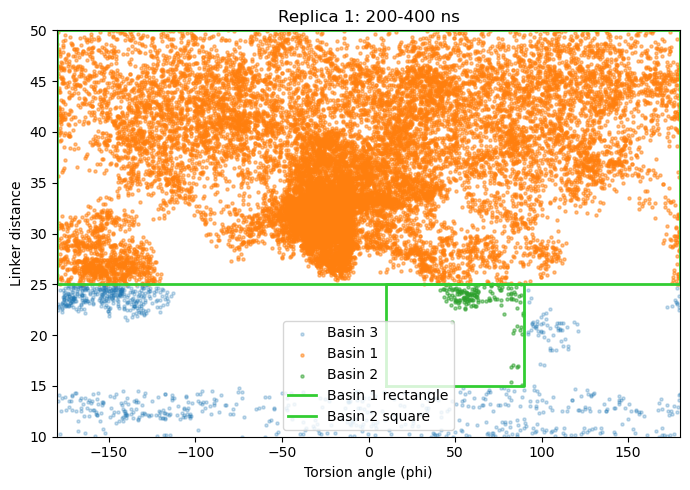

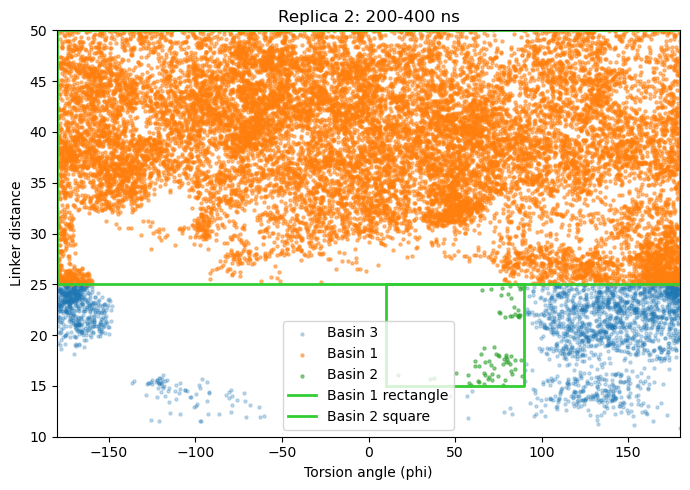

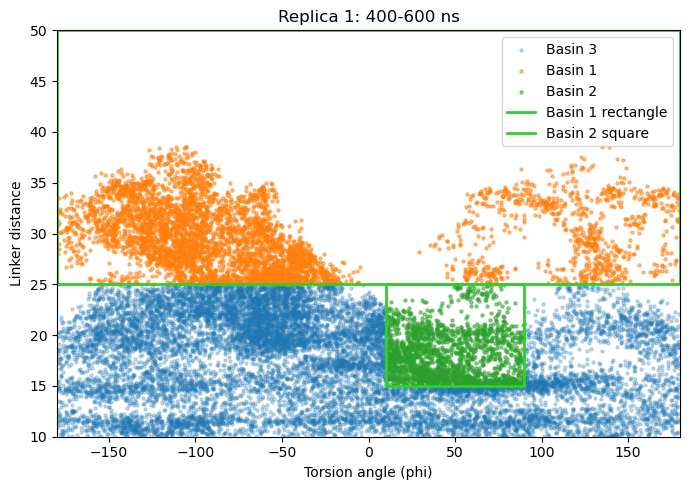

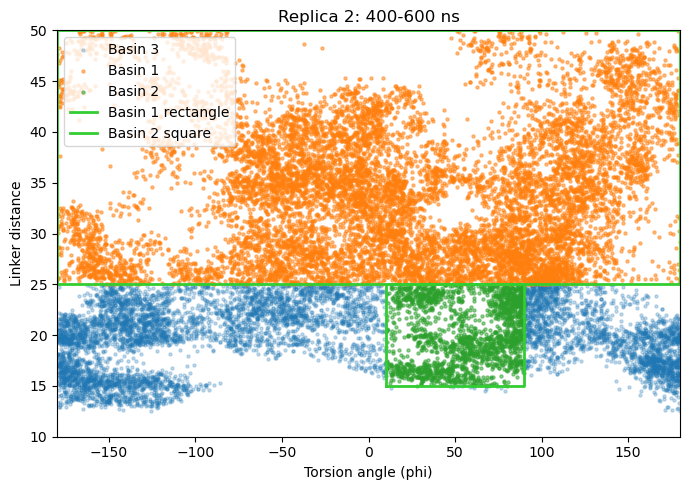

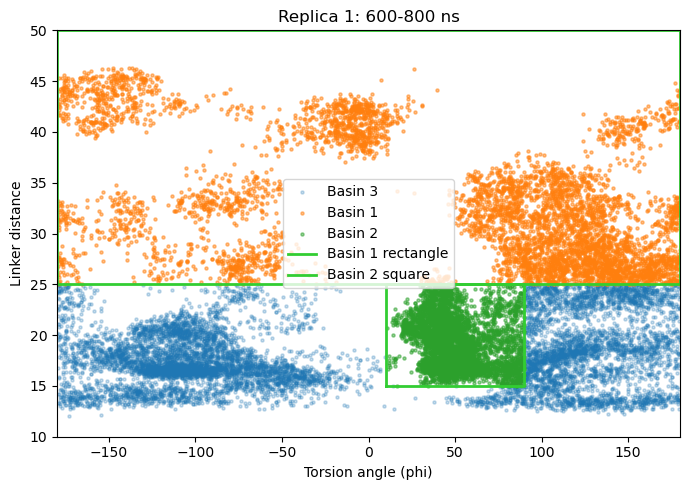

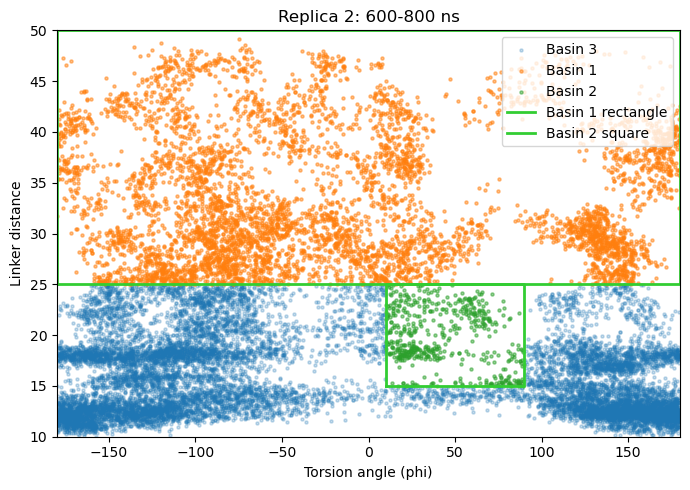

In [2]:
REPLICA_1_DIR = Path("Replica1") / "apo_p_hills"
REPLICA_2_DIR = Path("Replica2") / "apo_p_hills"

REPLICA_ZERO_REFS = {
    "Replica 1": 50010500.0,
    "Replica 2": 500.0,
}

TIMESTEPS_PER_NS = 1e6

SIM_TEMPERATURE = 310.0
kB = 0.0019872041
kBT = kB * SIM_TEMPERATURE

WINDOWS = [
    (200, 400),
    (400, 600),
    (600, 800),
]

PSEUDOCOUNT = 0.5
EPS = 1e-300

# ============================================================
# BASIN DEFINITION
# basin1 = upper green rectangle
# basin2 = small green square
# basin3 = everything else inside analysis box
# ============================================================

ANALYSIS_BOX = {
    "phi_min": -180.0,
    "phi_max": 180.0,
    "linker_min": 10.0,
    "linker_max": 50.0,
}


BASIN1_RECT = {
    "phi_min": -180.0,
    "phi_max": 180.0,
    "linker_min": 25.0,
    "linker_max": 50.0,
}

BASIN2_RECT = {
    "phi_min": 10.0,
    "phi_max": 90.0,
    "linker_min": 15.0,
    "linker_max": 25.0,
}

# ============================================================
# 2D PMF GRID SETTINGS
# ============================================================

PMF_PHI_EDGES = np.arange(-180, 180 + 10, 10)
PMF_LINKER_EDGES = np.arange(10, 50 + 1.5, 1.5)
MIN_CELL_COUNT = 1

# ============================================================
# FILE READING
# ============================================================

COLS = ["step", "phi", "linker", "sigma_phi", "sigma_linker", "hill_height"]

def get_hills_files(folder):
    files = sorted(folder.glob("*.hills.traj"))
    if not files:
        raise FileNotFoundError(f"No .hills.traj files found in: {folder}")
    return files

REPLICA_1_FILES = get_hills_files(REPLICA_1_DIR)
REPLICA_2_FILES = get_hills_files(REPLICA_2_DIR)

def read_hills_file(fname):
    df = pd.read_csv(fname, sep=r"\s+", comment="#", header=None)
    df = df.iloc[:, :6].copy()
    df.columns = COLS
    df["source_file"] = Path(fname).name
    return df

def load_replica(files, zero_ref, tmin=0.0, tmax=800.0):
    chunks = []
    for f in files:
        if not Path(f).exists():
            raise FileNotFoundError(f"Missing file: {f}")
        df = read_hills_file(f)
        df["time_ns"] = (df["step"] - zero_ref) / TIMESTEPS_PER_NS
        chunks.append(df)

    out = pd.concat(chunks, ignore_index=True)
    out = (
        out.sort_values("step")
           .drop_duplicates(subset=["step"], keep="first")
           .reset_index(drop=True)
    )

    out["phi"] = ((out["phi"] + 180.0) % 360.0) - 180.0
    out = out[(out["time_ns"] >= tmin) & (out["time_ns"] <= tmax)].copy()
    out.reset_index(drop=True, inplace=True)
    return out

# ============================================================
# BASIN ASSIGNMENT
# ============================================================

def in_rect(phi, linker, rect):
    return (
        (phi >= rect["phi_min"]) &
        (phi <= rect["phi_max"]) &
        (linker >= rect["linker_min"]) &
        (linker <= rect["linker_max"])
    )

def assign_basins(df):
    df = df.copy()

    in_box = (
        (df["phi"] >= ANALYSIS_BOX["phi_min"]) &
        (df["phi"] <= ANALYSIS_BOX["phi_max"]) &
        (df["linker"] >= ANALYSIS_BOX["linker_min"]) &
        (df["linker"] <= ANALYSIS_BOX["linker_max"])
    )

    # Basin 1 gets priority on the shared boundary linker=25.0
    basin1 = in_box & in_rect(df["phi"], df["linker"], BASIN1_RECT)
    basin2 = in_box & (~basin1) & in_rect(df["phi"], df["linker"], BASIN2_RECT)
    basin3 = in_box & (~basin1) & (~basin2)

    df["in_box"] = in_box
    df["basin1"] = basin1
    df["basin2"] = basin2
    df["basin3"] = basin3
    return df

rep1 = assign_basins(load_replica(REPLICA_1_FILES, REPLICA_ZERO_REFS["Replica 1"]))
rep2 = assign_basins(load_replica(REPLICA_2_FILES, REPLICA_ZERO_REFS["Replica 2"]))

# ============================================================
# HELPERS
# ============================================================

def subset_window(df, t0, t1):
    return df[(df["time_ns"] >= t0) & (df["time_ns"] < t1)].copy()

def counts_from_df(df):
    d = df[df["in_box"]].copy()
    n1 = int(d["basin1"].sum())
    n2 = int(d["basin2"].sum())
    n3 = int(d["basin3"].sum())
    ntot = n1 + n2 + n3
    return n1, n2, n3, ntot

def probs_from_counts(n1, n2, n3):
    ntot = n1 + n2 + n3
    if ntot == 0:
        return np.nan, np.nan, np.nan
    return n1 / ntot, n2 / ntot, n3 / ntot

def basin_free_energies_from_counts(n1, n2, n3, alpha=PSEUDOCOUNT):
    ntot = n1 + n2 + n3
    if ntot == 0:
        return np.nan, np.nan, np.nan

    p1s = (n1 + alpha) / (ntot + 3 * alpha)
    p2s = (n2 + alpha) / (ntot + 3 * alpha)
    p3s = (n3 + alpha) / (ntot + 3 * alpha)

    F1 = -kBT * np.log(p1s + EPS)
    F2 = -kBT * np.log(p2s + EPS)
    F3 = -kBT * np.log(p3s + EPS)
    return F1, F2, F3

# ============================================================
# 2D PMF MINIMA
# ============================================================

def build_grid_basin_masks(phi_edges, linker_edges):
    phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    linker_centers = 0.5 * (linker_edges[:-1] + linker_edges[1:])

    PHI, LINK = np.meshgrid(phi_centers, linker_centers, indexing="ij")

    in_box_mask = (
        (PHI >= ANALYSIS_BOX["phi_min"]) &
        (PHI <= ANALYSIS_BOX["phi_max"]) &
        (LINK >= ANALYSIS_BOX["linker_min"]) &
        (LINK <= ANALYSIS_BOX["linker_max"])
    )

    basin1_mask = in_box_mask & in_rect(PHI, LINK, BASIN1_RECT)
    basin2_mask = in_box_mask & (~basin1_mask) & in_rect(PHI, LINK, BASIN2_RECT)
    basin3_mask = in_box_mask & (~basin1_mask) & (~basin2_mask)

    return phi_centers, linker_centers, basin1_mask, basin2_mask, basin3_mask

(
    PMF_PHI_CENTERS,
    PMF_LINKER_CENTERS,
    PMF_BASIN1_MASK,
    PMF_BASIN2_MASK,
    PMF_BASIN3_MASK,
) = build_grid_basin_masks(PMF_PHI_EDGES, PMF_LINKER_EDGES)

def window_pmf_from_df(df, phi_edges=PMF_PHI_EDGES, linker_edges=PMF_LINKER_EDGES, alpha=PSEUDOCOUNT):
    d = df[df["in_box"]].copy()
    shape = (len(phi_edges) - 1, len(linker_edges) - 1)

    if len(d) == 0:
        return np.full(shape, np.nan), np.zeros(shape, dtype=int)

    H, _, _ = np.histogram2d(
        d["phi"].to_numpy(),
        d["linker"].to_numpy(),
        bins=[phi_edges, linker_edges]
    )

    H = H.astype(float)
    total = H.sum()
    nbins = H.size

    P = (H + alpha) / (total + alpha * nbins)
    F = -kBT * np.log(P + EPS)
    F = F - np.nanmin(F)

    return F, H

def basin_minima_from_pmf(F, H, min_cell_count=MIN_CELL_COUNT):
    masks = {
        "1": PMF_BASIN1_MASK,
        "2": PMF_BASIN2_MASK,
        "3": PMF_BASIN3_MASK,
    }

    out = {}
    for key, mask in masks.items():
        valid = mask & (H >= min_cell_count)
        if not np.any(valid):
            out[f"Emin{key}"] = np.nan
            out[f"phi_min{key}"] = np.nan
            out[f"linker_min{key}"] = np.nan
        else:
            Fgrid = np.where(valid, F, np.nan)
            idx = np.unravel_index(np.nanargmin(Fgrid), Fgrid.shape)
            out[f"Emin{key}"] = Fgrid[idx]
            out[f"phi_min{key}"] = PMF_PHI_CENTERS[idx[0]]
            out[f"linker_min{key}"] = PMF_LINKER_CENTERS[idx[1]]
    return out

def minimum_gap_from_window_df(df):
    F, H = window_pmf_from_df(df)
    return basin_minima_from_pmf(F, H)

# ============================================================
# DIRECT PER-REPLICA TABLES: MAIN / MINIMA
# ============================================================

def per_replica_window_table(rep_df, replica_name):
    rows = []

    for t0, t1 in WINDOWS:
        wdf = subset_window(rep_df, t0, t1)

        N1, N2, N3, Ntot = counts_from_df(wdf)
        P1, P2, P3 = probs_from_counts(N1, N2, N3)
        F1, F2, F3 = basin_free_energies_from_counts(N1, N2, N3)
        min_stats = minimum_gap_from_window_df(wdf)

        rows.append({
            "replica": replica_name,
            "window": f"{int(t0)}-{int(t1)}",
            "rows_total": len(wdf),
            "rows_in_box": int(wdf["in_box"].sum()),

            "N1": N1,
            "N2": N2,
            "N3": N3,
            "Ntot": Ntot,

            "P1": P1,
            "P2": P2,
            "P3": P3,

            "F1": F1,
            "F2": F2,
            "F3": F3,

            "Emin1": min_stats["Emin1"],
            "phi_min1": min_stats["phi_min1"],
            "linker_min1": min_stats["linker_min1"],

            "Emin2": min_stats["Emin2"],
            "phi_min2": min_stats["phi_min2"],
            "linker_min2": min_stats["linker_min2"],

            "Emin3": min_stats["Emin3"],
            "phi_min3": min_stats["phi_min3"],
            "linker_min3": min_stats["linker_min3"],
        })

    out = pd.DataFrame(rows)

    main_table = out[[
        "replica", "window",
        "rows_total", "rows_in_box",
        "N1", "N2", "N3", "Ntot",
        "P1", "P2", "P3",
        "F1", "F2", "F3",
    ]].copy()

    minima_table = out[[
        "replica", "window",
        "Emin1", "phi_min1", "linker_min1",
        "Emin2", "phi_min2", "linker_min2",
        "Emin3", "phi_min3", "linker_min3",
    ]].copy()

    print(f"\n=== {replica_name} MAIN TABLE ===")
    display(main_table.round(4))

    print(f"\n=== {replica_name} MINIMA TABLE ===")
    display(minima_table.round(4))

    return out, main_table, minima_table

rep1_all, rep1_main, rep1_minima = per_replica_window_table(rep1, "Replica 1")
rep2_all, rep2_main, rep2_minima = per_replica_window_table(rep2, "Replica 2")

# ============================================================
# SANITY CHECK PLOTS
# ============================================================

def draw_rect(ax, rect, label=None, color="limegreen", lw=2):
    x0, x1 = rect["phi_min"], rect["phi_max"]
    y0, y1 = rect["linker_min"], rect["linker_max"]
    xs = [x0, x1, x1, x0, x0]
    ys = [y0, y0, y1, y1, y0]
    ax.plot(xs, ys, color=color, linewidth=lw, label=label)

def sanity_plot(rep_df, replica_name, t0, t1, max_points=20000):
    wdf = subset_window(rep_df, t0, t1).copy()
    wdf = wdf[wdf["in_box"]].copy()

    if len(wdf) == 0:
        print(f"{replica_name} {t0}-{t1}: no in-box points")
        return

    if len(wdf) > max_points:
        wdf = wdf.sample(max_points, random_state=0)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        wdf.loc[wdf["basin3"], "phi"],
        wdf.loc[wdf["basin3"], "linker"],
        s=5, alpha=0.25, label="Basin 3"
    )
    ax.scatter(
        wdf.loc[wdf["basin1"], "phi"],
        wdf.loc[wdf["basin1"], "linker"],
        s=5, alpha=0.5, label="Basin 1"
    )
    ax.scatter(
        wdf.loc[wdf["basin2"], "phi"],
        wdf.loc[wdf["basin2"], "linker"],
        s=5, alpha=0.5, label="Basin 2"
    )

    draw_rect(ax, BASIN1_RECT, label="Basin 1 rectangle")
    draw_rect(ax, BASIN2_RECT, label="Basin 2 square")

    ax.set_xlim(ANALYSIS_BOX["phi_min"], ANALYSIS_BOX["phi_max"])
    ax.set_ylim(ANALYSIS_BOX["linker_min"], ANALYSIS_BOX["linker_max"])
    ax.set_xlabel("Torsion angle (phi)")
    ax.set_ylabel("Linker distance")
    ax.set_title(f"{replica_name}: {t0}-{t1} ns")
    ax.legend()
    plt.tight_layout()
    plt.show()

for t0, t1 in WINDOWS:
    sanity_plot(rep1, "Replica 1", t0, t1)
    sanity_plot(rep2, "Replica 2", t0, t1)

# ============================================================
# ORANGE BASIN (BASIN 1) DELTA F
# DeltaF_orange = F_rest - F1
# where rest = Basin2 + Basin3
# positive => orange basin is favored
# ============================================================

def add_orange_basin_deltaF(df):
    df = df.copy()

    p1s = (df["N1"] + PSEUDOCOUNT) / (df["Ntot"] + 3 * PSEUDOCOUNT)
    p2s = (df["N2"] + PSEUDOCOUNT) / (df["Ntot"] + 3 * PSEUDOCOUNT)
    p3s = (df["N3"] + PSEUDOCOUNT) / (df["Ntot"] + 3 * PSEUDOCOUNT)

    p_rest = p2s + p3s

    df["F_rest"] = -kBT * np.log(p_rest + EPS)
    df["deltaF_orange"] = df["F_rest"] - df["F1"]

    return df

rep1_all = add_orange_basin_deltaF(rep1_all)
rep2_all = add_orange_basin_deltaF(rep2_all)

In [6]:

def summarize_six_F_values(rep1_df, rep2_df, colname, label):
    all_vals = np.concatenate([
        rep1_df[colname].dropna().to_numpy(dtype=float),
        rep2_df[colname].dropna().to_numpy(dtype=float),
    ])

    n_all = len(all_vals)
    mean_all = np.mean(all_vals) if n_all > 0 else np.nan
    sd_all = np.std(all_vals, ddof=1) if n_all > 1 else np.nan
    sem_all = sd_all / np.sqrt(n_all) if n_all > 1 else np.nan

    summary_df = pd.DataFrame([{
        "group": label,
        "n_F": n_all,
        "F_values": ", ".join([f"{x:.4f}" for x in all_vals]),
        "F_mean": mean_all,
        "F_SD_across_windows": sd_all,
        "F_SEM_across_windows": sem_all,
    }])

    return summary_df

final_F1_summary = summarize_six_F_values(
    rep1_all, rep2_all,
    "F1",
    "All 6 F1 values"
)

final_F2_summary = summarize_six_F_values(
    rep1_all, rep2_all,
    "F2",
    "All 6 F2 values"
)

final_F3_summary = summarize_six_F_values(
    rep1_all, rep2_all,
    "F3",
    "All 6 F3 values"
)

print("=== FINAL F1 SUMMARY TABLE ===")
display(final_F1_summary.round(4))

print("=== FINAL F2 SUMMARY TABLE ===")
display(final_F2_summary.round(4))

print("=== FINAL F3 SUMMARY TABLE ===")
display(final_F3_summary.round(4))


# ============================================================
# PAIRWISE DIFFERENCES FROM SUMMARY MEANS
# like in your sketch:
# diff = mean(A) - mean(B)
# SEM_diff = sqrt( SEM_A^2 + SEM_B^2 )
# ============================================================

F1_mean = final_F1_summary.loc[0, "F_mean"]
F1_sem  = final_F1_summary.loc[0, "F_SEM_across_windows"]

F2_mean = final_F2_summary.loc[0, "F_mean"]
F2_sem  = final_F2_summary.loc[0, "F_SEM_across_windows"]

F3_mean = final_F3_summary.loc[0, "F_mean"]
F3_sem  = final_F3_summary.loc[0, "F_SEM_across_windows"]

pairwise_from_means = pd.DataFrame([
    {
        "comparison": "F2 - F1",
        "difference_of_means": F2_mean - F1_mean,
        "propagated_SEM": np.sqrt(F2_sem**2 + F1_sem**2),
        "reported_as": f"{(F2_mean - F1_mean):.4f} ± {np.sqrt(F2_sem**2 + F1_sem**2):.4f}",
    },
    {
        "comparison": "F3 - F1",
        "difference_of_means": F3_mean - F1_mean,
        "propagated_SEM": np.sqrt(F3_sem**2 + F1_sem**2),
        "reported_as": f"{(F3_mean - F1_mean):.4f} ± {np.sqrt(F3_sem**2 + F1_sem**2):.4f}",
    },
])

print("=== PAIRWISE DELTA F FROM SUMMARY MEANS TABLE ===")
display(pairwise_from_means.round(4))

=== FINAL F1 SUMMARY TABLE ===


,group,n_F,F_values,F_mean,F_SD_across_windows,F_SEM_across_windows
0,All 6 F1 values,6,"0.0354, 0.8602, 0.7658, 0.0732, 0.3498, 0.7856",0.4783,0.3741,0.1527


=== FINAL F2 SUMMARY TABLE ===


,group,n_F,F_values,F_mean,F_SD_across_windows,F_SEM_across_windows
0,All 6 F2 values,6,"3.0682, 1.4231, 0.8564, 3.5520, 1.4612, 2.2201",2.0968,1.0462,0.4271


=== FINAL F3 SUMMARY TABLE ===


,group,n_F,F_values,F_mean,F_SD_across_windows,F_SEM_across_windows
0,All 6 F3 values,6,"1.8581, 0.2623, 0.4750, 1.3657, 0.6647, 0.2256",0.8086,0.6606,0.2697


=== PAIRWISE DELTA F FROM SUMMARY MEANS TABLE ===


,comparison,difference_of_means,propagated_SEM,reported_as
0,F2 - F1,1.6185,0.4536,1.6185 ± 0.4536
1,F3 - F1,0.3302,0.3099,0.3302 ± 0.3099
